# Descrição do projeto
A rede de academias Model Fitness está desenvolvendo uma estratégia de interação 
com o cliente baseados em dados analíticos.

Um dos problemas mais comuns que academias e outros serviços enfrentam é a 
rotatividade de clientes. Como você sabe se um cliente não está mais com você? Você 
pode calcular a rotatividade baseado nas pessoas que se livram das suas contas ou 
não renovam seus contratos. No entanto, às vezes não é óbvio que um cliente saiu.

# Visão geral dos dados

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
data = pd.read_csv("./datasets/gym_churn_us.csv")
data.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [4]:
data.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [5]:
data.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Com base nas médias do dados apresentados, promover mais contratos de maior duração (6 meses à 1 ano, por exemplo) e incentivar a frequência maior nas aulas seriam formas de manter mais os clientes

In [6]:
churn = data[data['Churn'] == 1]
stayed = data[data['Churn'] == 0]

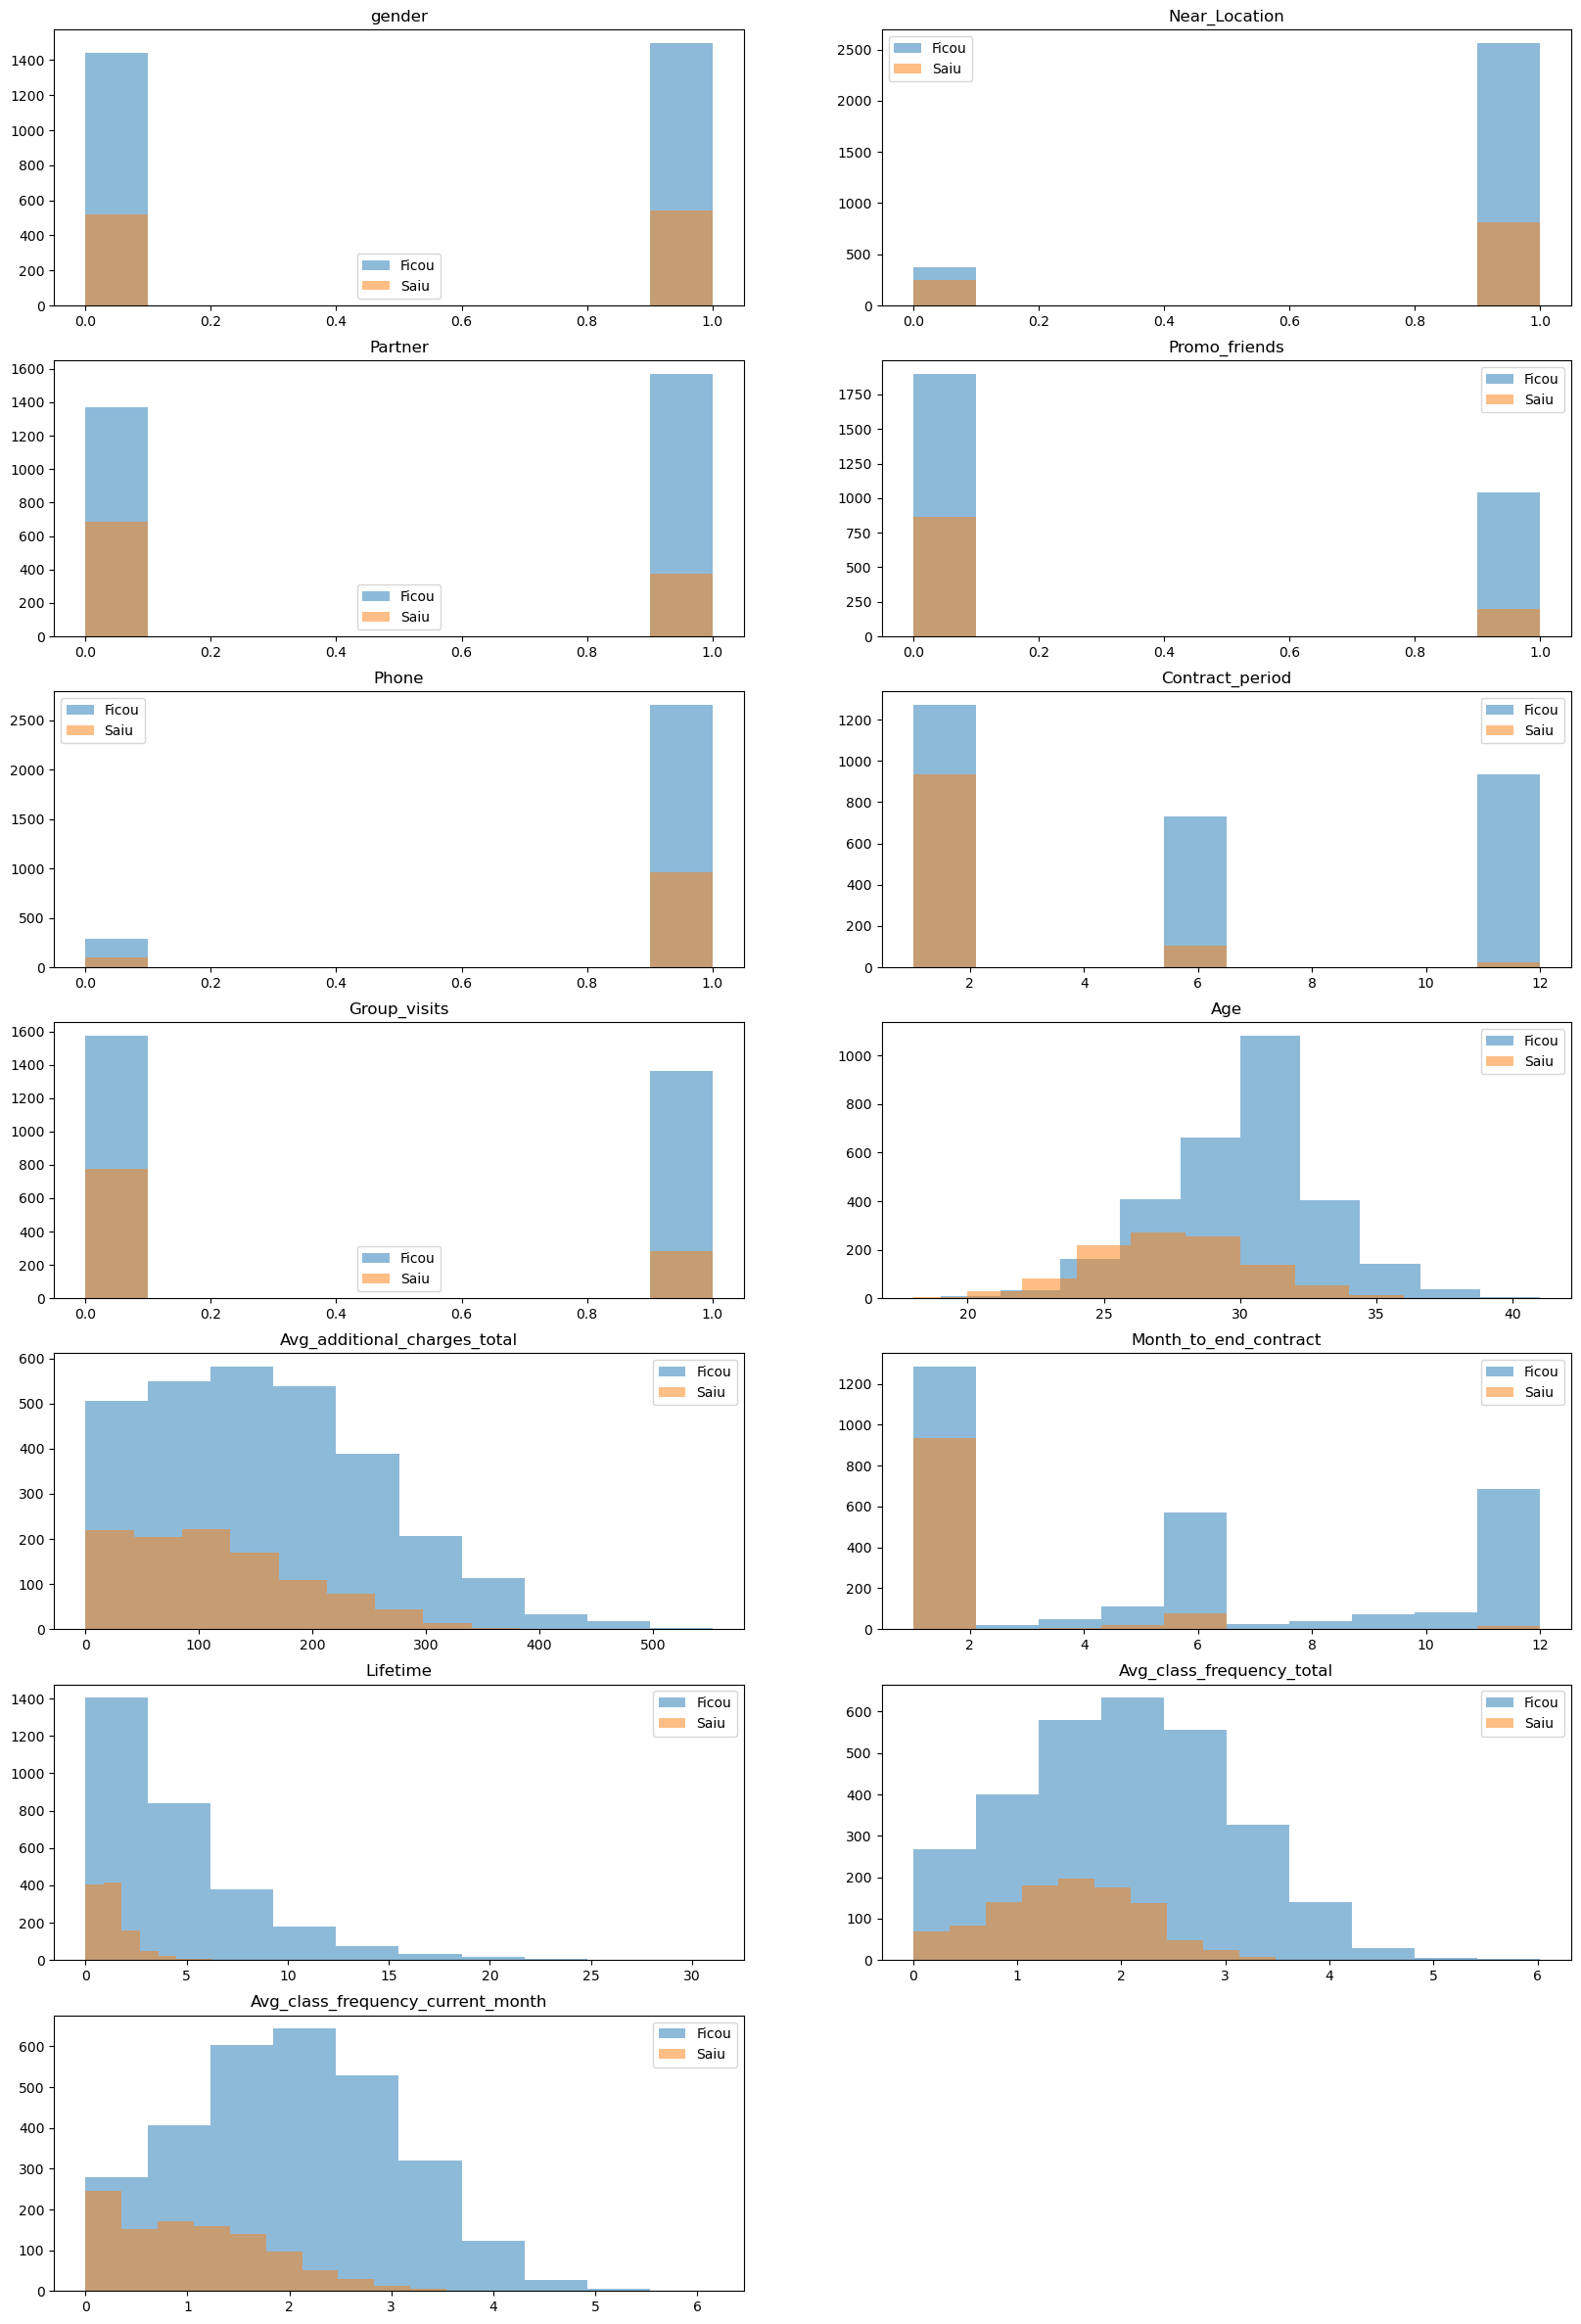

In [7]:
fig, axes = plt.subplots(7, 2, figsize=(20, 30))

colunas = data.select_dtypes(include='number').columns.to_list()

for ax, col in zip(axes.flatten(), colunas):
    ax.hist(stayed[col], alpha=0.5, label='Ficou')
    ax.hist(churn[col], alpha=0.5, label='Saiu')
    ax.legend()
    ax.set_title(col)

axes.flatten()[-1].set_visible(False)

In [8]:
heatmap = data.select_dtypes(include='number').corr()
heatmap

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.013579,0.014620,0.009156,0.000708
Near_Location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.070921,0.043127,0.062664,-0.128098
Partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.061229,0.024938,0.045561,-0.157986
Promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.072721,0.028063,0.053768,-0.162233
Phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018801,0.008340,0.013375,-0.001177
Contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.170725,0.096211,0.159407,-0.389984
Group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.075853,0.056695,0.075923,-0.175325
Age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.164693,0.119953,0.183095,-0.404735
Avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.079028,0.044426,0.079570,-0.198697
Month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.161078,0.085387,0.147605,-0.381393


<Axes: >

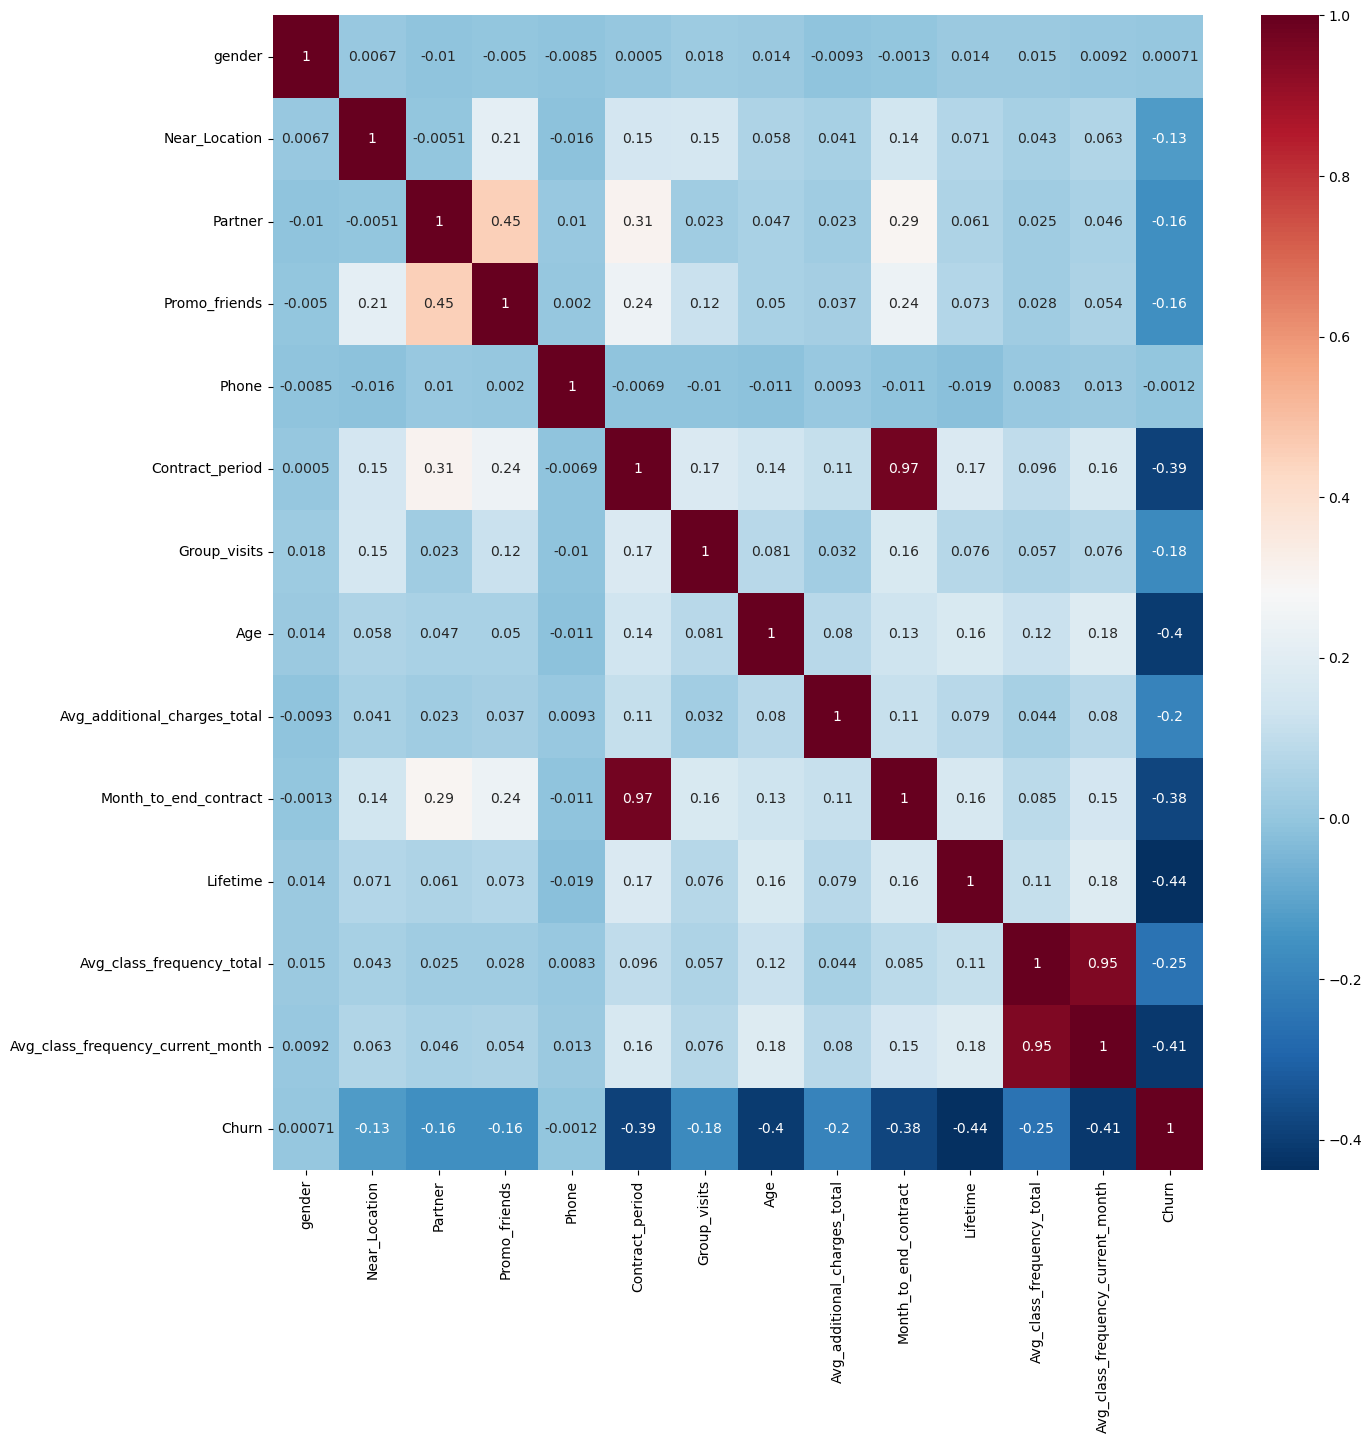

In [9]:
f, ax = plt.subplots(figsize=(15, 15))
sns.heatmap(heatmap, annot=True, cmap="RdBu_r")

Clientes com maior Lifetime já criaram um hábito e provavelmente estão mais satisfeitos com a academia, o que reduz a chance de cancelamento. Já clientes com Lifetime baixo são clientes novos, que ainda não criaram o hábito e ainda estão "testando" a academia. Por isso, tendem a ter maior chance de Churn.

# Escolhendo um modelo de classificação

In [10]:
data = pd.get_dummies(data)
print(data.shape)
data.head()

(4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [11]:
X=data.drop(columns=['Churn'])
y=data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train)
print(X_train_st[:5])

[[-1.02020406  0.41949551 -0.98300159 -0.68037116  0.31311215 -0.82102345
  -0.85408585 -1.88824527 -0.75522726 -0.80401253 -0.45840986 -1.22326715
  -1.66076447]
 [ 0.98019606 -2.38381576 -0.98300159 -0.68037116  0.31311215  0.27681116
  -0.85408585 -0.04144312  0.72868936  0.38447606  1.14702805 -0.65157706
  -0.59370522]
 [-1.02020406  0.41949551  1.01729235 -0.68037116  0.31311215 -0.82102345
  -0.85408585  0.88195795  0.67344225 -0.80401253 -0.19083688  0.40130419
   0.36921144]
 [-1.02020406  0.41949551  1.01729235  1.469786    0.31311215  1.59421269
   1.17084249 -1.58044491 -0.55851686  1.81066236 -0.99355583 -0.49907205
  -0.33370157]
 [-1.02020406 -2.38381576  1.01729235 -0.68037116  0.31311215 -0.82102345
  -0.85408585  0.88195795 -0.85576453 -0.80401253  1.14702805 -0.30643147
  -0.13833124]]


In [12]:
X_test_st = scaler.transform(X_test)

models = [LogisticRegression(random_state=0), RandomForestClassifier(random_state=0)]

Avalie acurácia, precisão e sensibilidade para ambos os modelos usando dados de validação. Use-os para comparar os modelos. Qual modelo rendeu melhores resultados?

Lembre-se de indicar o parâmetro random_state quando dividir os dados e definir o algoritmo.

In [13]:
for model in models:
    model.fit(X_train_st, y_train)
    y_pred = model.predict(X_test_st)
    print('Model: {} accuracy:{:.2f} precision:{:.2f} recall:{:.2f}'.format(model, accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred)))

Model: LogisticRegression(random_state=0) accuracy:0.92 precision:0.87 recall:0.84
Model: RandomForestClassifier(random_state=0) accuracy:0.92 precision:0.85 recall:0.83


O LogisticRegression seria a melhor escolha porque tem o maior Recall

In [14]:
final_model = LogisticRegression(random_state=0)
final_model.fit(X_train_st, y_train)
y_pred = final_model.predict(X_test_st)

In [15]:
importances = final_model.coef_.ravel()

fi_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

feature_weights = fi_df.rename(columns={'importance': 'coeff'})

fi_df.sort_values('importance', ascending=False)
fi_df.sort_values('importance', ascending = False)

,feature,importance
11,Avg_class_frequency_total,3.082208
4,Phone,0.010360
0,gender,-0.034543
1,Near_Location,-0.081161
2,Partner,-0.092043
3,Promo_friends,-0.295909
6,Group_visits,-0.434622
8,Avg_additional_charges_total,-0.526969
9,Month_to_end_contract,-0.564901
5,Contract_period,-0.746513


C:\Users\Vitor\AppData\Local\Temp\ipykernel_2312\1549148093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_weights, x='coeff', y='feature', palette='RdBu_r')


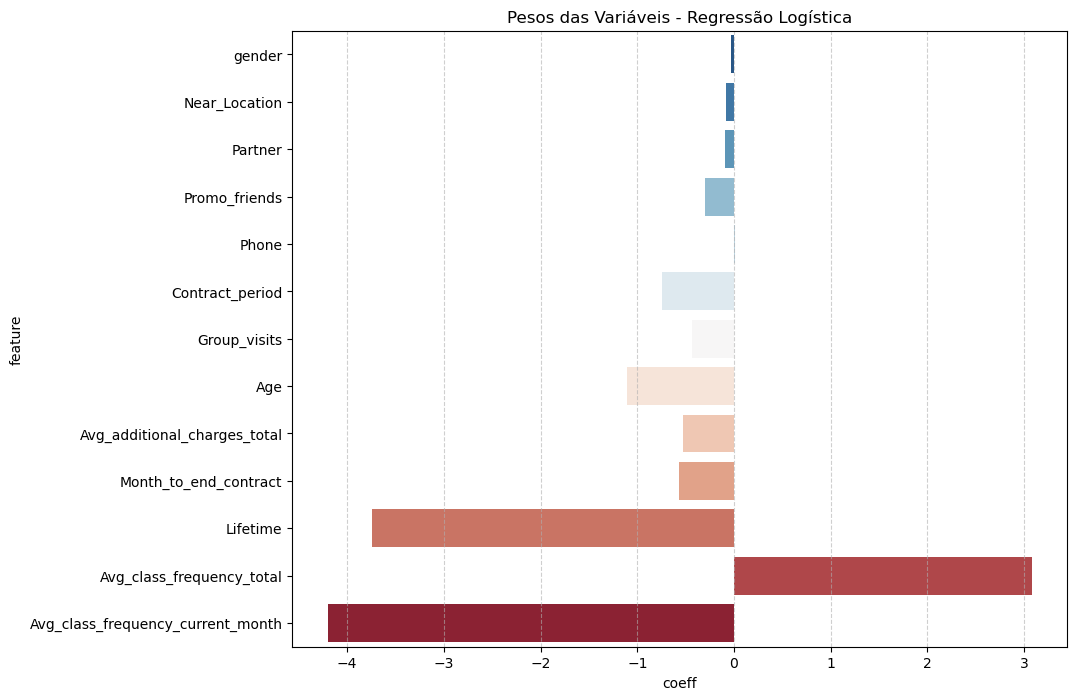

In [16]:
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_weights, x='coeff', y='feature', palette='RdBu_r')
plt.title('Pesos das Variáveis - Regressão Logística')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [17]:
X_st = scaler.transform(X)

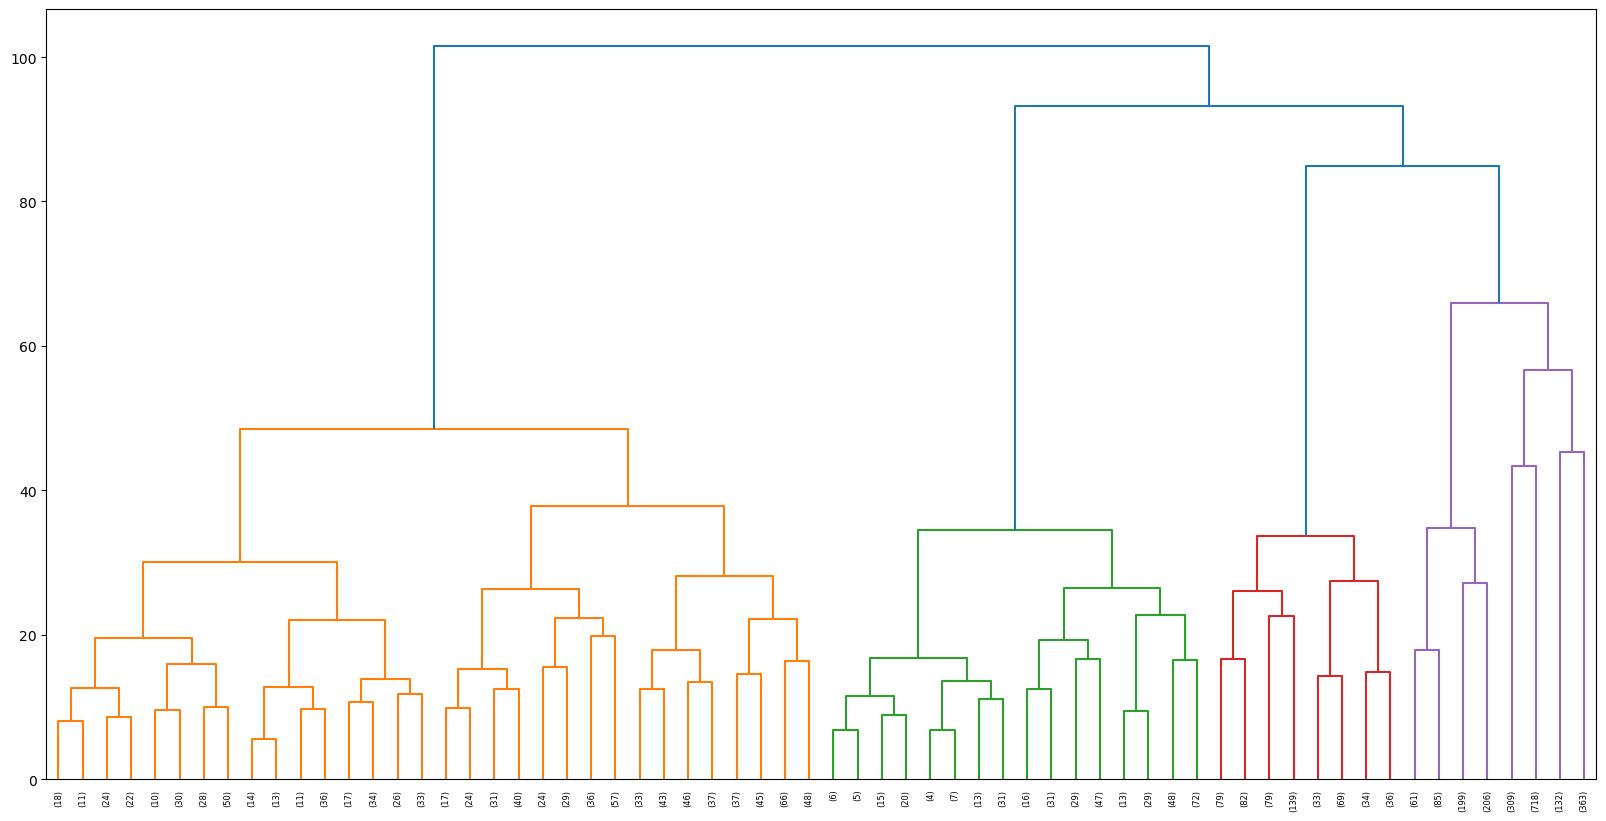

In [18]:
linked = linkage(X_st, method = 'ward')
plt.figure(figsize=(20, 10))
dendrogram(linked, orientation='top', truncate_mode='level', p=5)
plt.show()

# Definindo a segmentação

In [19]:
km = KMeans(n_clusters=5, random_state=0)
labels = km.fit_predict(X_st)

data['cluster_km']=labels

data.groupby(['cluster_km']).mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster_km,,,,,,,,,,,,,,
0,0.482456,1.000000,0.243860,0.010526,0.903509,1.968421,0.321930,28.222807,131.195036,1.885965,2.439474,1.318827,1.083440,0.517544
1,0.599196,0.971850,0.285523,0.121984,0.892761,2.911528,0.487936,30.351206,164.069371,2.667560,5.257373,2.927754,2.935896,0.050938
2,0.495430,0.000000,0.466179,0.076782,0.915905,2.243144,0.213894,28.486289,133.939051,2.100548,2.819013,1.659922,1.470159,0.447898
3,0.499468,0.945687,0.741214,0.490948,0.899894,11.865815,0.552716,29.903088,165.187155,10.854100,4.729499,1.990679,1.981940,0.022364
4,0.484076,1.000000,0.804140,1.000000,0.910828,3.089172,0.449045,29.076433,139.237930,2.882166,3.523885,1.674024,1.556829,0.265924


In [20]:
cluster_means = data.groupby('cluster_km').mean()

cluster_means['Churn'].sort_values(ascending=False)

cluster_km
0    0.517544
2    0.447898
4    0.265924
1    0.050938
3    0.022364
Name: Churn, dtype: float64

In [21]:
churn_por_cluster = (cluster_means['Churn'] * 100).sort_values(ascending=False).round(1)
churn_por_cluster

cluster_km
0    51.8
2    44.8
4    26.6
1     5.1
3     2.2
Name: Churn, dtype: float64

In [22]:
cluster_means = data.groupby('cluster_km').mean()
cluster_means[['Contract_period', 'Lifetime', 'Avg_class_frequency_total', 'Age', 'Churn']].sort_values('Churn', ascending=False)

,Contract_period,Lifetime,Avg_class_frequency_total,Age,Churn
cluster_km,,,,,
0,1.968421,2.439474,1.318827,28.222807,0.517544
2,2.243144,2.819013,1.659922,28.486289,0.447898
4,3.089172,3.523885,1.674024,29.076433,0.265924
1,2.911528,5.257373,2.927754,30.351206,0.050938
3,11.865815,4.729499,1.990679,29.903088,0.022364


- Risco Crítico (cluster 0): Contrato mais curto, menor frequência e menor tempo de casa de todos
- Altamente Engajados (cluster 1): Maior frequência e maior tempo de casa de todos os grupos, contrato de duração média-alta
- Alto Risco (cluster 2): Contrato curto, frequência baixa-moderada
- Fidelizados por Contrato (cluster 3): Retido pelo contrato longo, mesmo sem ser o mais engajado
- Risco Moderado (cluster 4): Contrato médio (~6 meses), frequência e tempo de casa medianos

de acordo com as médias de cada agrupamento, clientes com maior risco de churn tem menos frequência, tempo desde a primeira vez na academia, idade e participações nas sessões em grupo, sendo posicionados no cluster 0

notificações por meio de telefone sobre aulas coletivas, descontos na renovação do contrato quando estiver perto do vencimento,mudar o linguajar para uma comunicação mais proxima ao do jovem e criar novas medidas de engajamento, como gamificação, seriam outros tipos de estratégias que auxiliariam a retenção de clientes

# Métricas por coluna e cluster

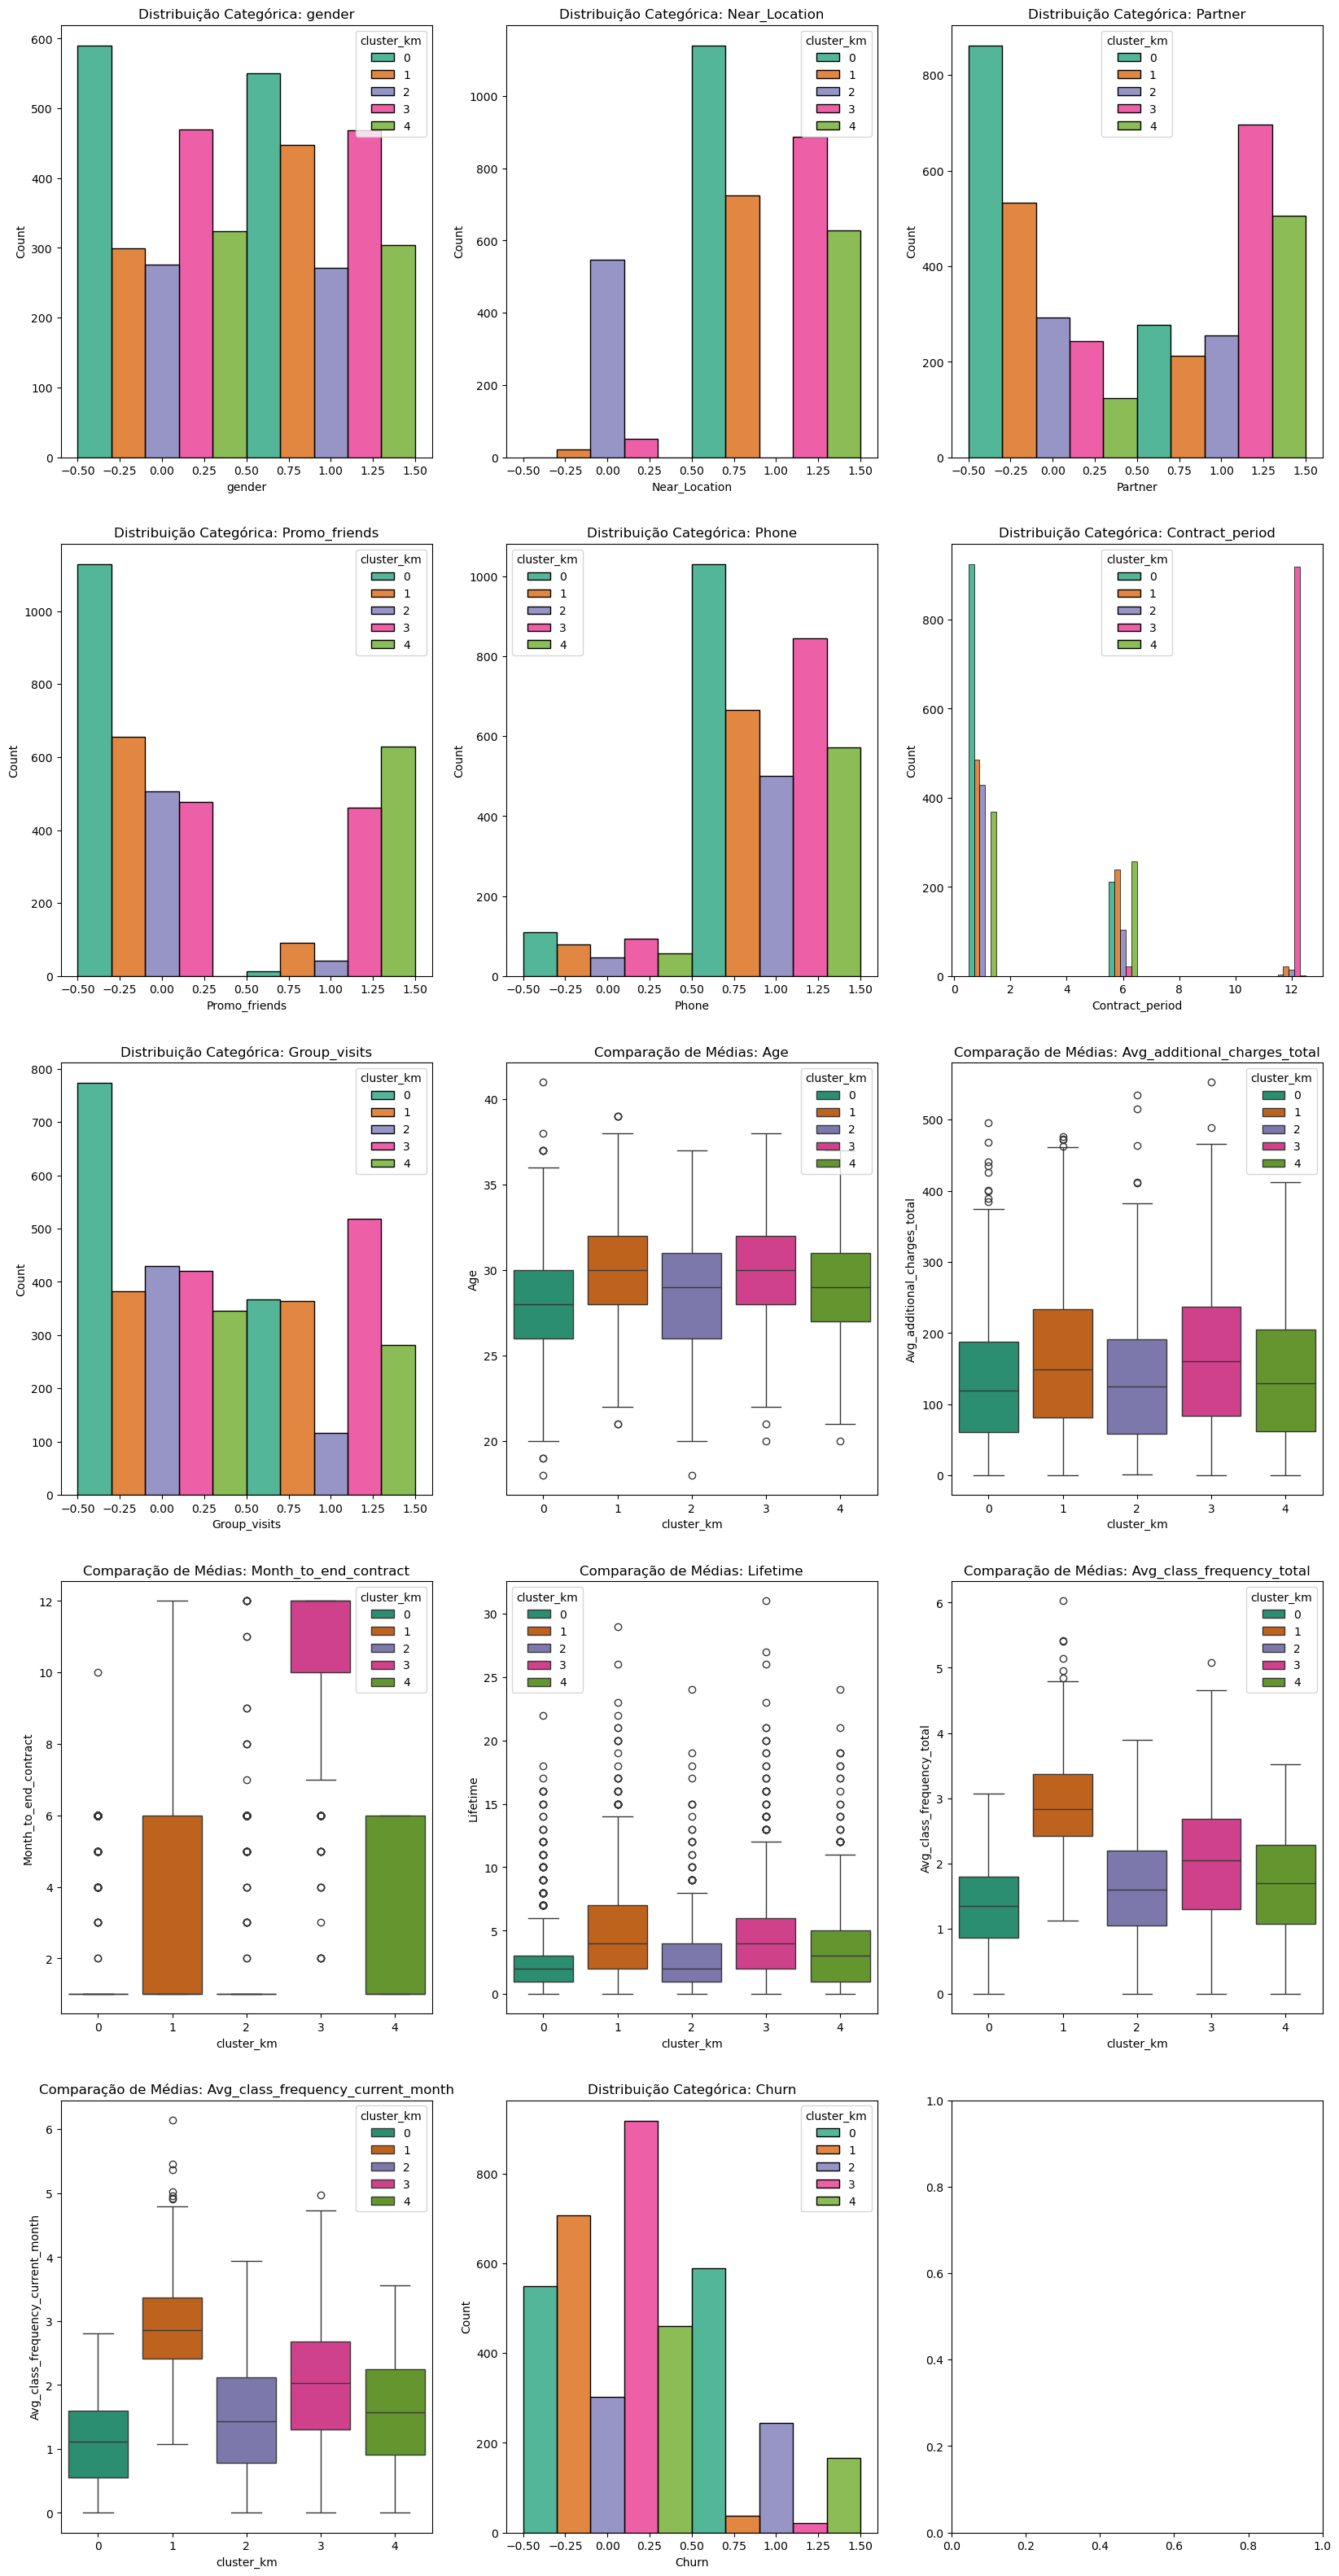

In [23]:
fig, axes = plt.subplots(5, 3, figsize=(20, 40))
colunas = data.select_dtypes(include='number').columns.drop('cluster_km').to_list()

for ax, col in zip(axes.flatten(), colunas):
    values = data[col].nunique()
    
    # Lógica para Variáveis Discretas (Gênero, Localização, etc.)
    if values <= 3:
        sns.histplot(data=data, x=col, hue='cluster_km', 
                     discrete=True, multiple='dodge', 
                     ax=ax, palette='Dark2')
        ax.set_title(f"Distribuição Categórica: {col}")
    
    # Lógica para Variáveis Contínuas (Idade, Frequência, Gastos)
    else:
        # Trocamos o histograma pelo Box Plot para clareza total
        sns.boxplot(data=data, x='cluster_km', y=col, 
                    ax=ax, palette='Dark2', hue='cluster_km')
        ax.set_title(f"Comparação de Médias: {col}")

# gráficos para publicação

## Seção 1

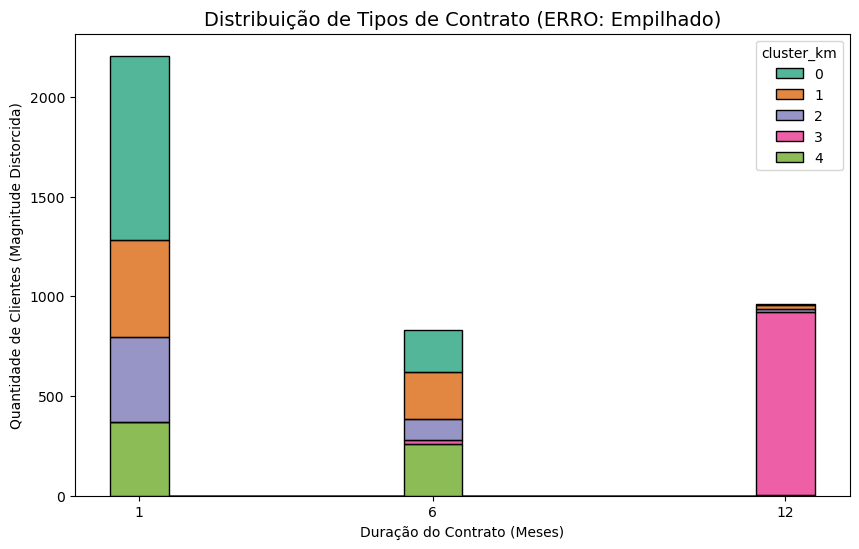

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Contract_period', hue='cluster_km', 
             multiple='stack', palette='Dark2', discrete=True)

plt.title('Distribuição de Tipos de Contrato (ERRO: Empilhado)', fontsize=14)
plt.xlabel('Duração do Contrato (Meses)')
plt.ylabel('Quantidade de Clientes (Magnitude Distorcida)')
plt.xticks([1, 6, 12])
plt.savefig('./images/erro_stack_contract.png', dpi=300, bbox_inches='tight')
plt.show()

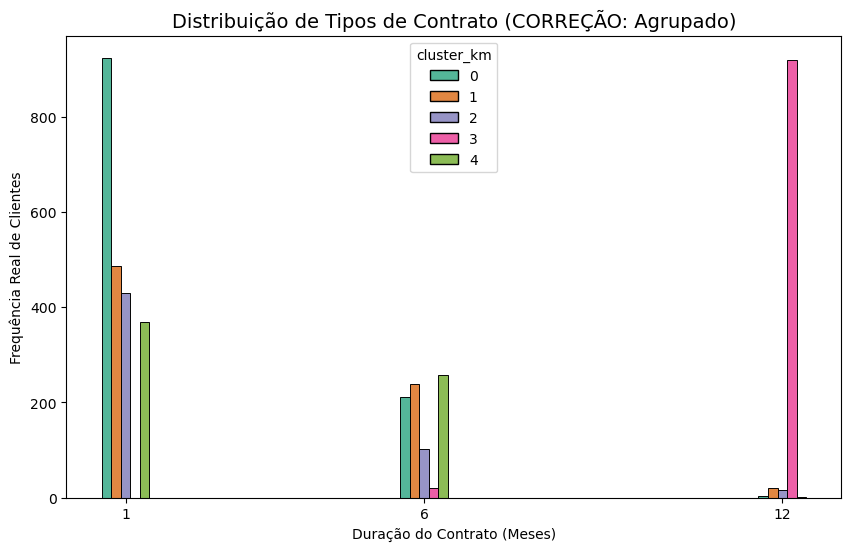

In [25]:
plt.figure(figsize=(10, 6))
# O agrupamento permite comparar a altura real de cada cluster a partir do zero
sns.histplot(data=data, x='Contract_period', hue='cluster_km', 
             multiple='dodge', shrink=0.8, palette='Dark2', discrete=True)

plt.title('Distribuição de Tipos de Contrato (CORREÇÃO: Agrupado)', fontsize=14)
plt.xlabel('Duração do Contrato (Meses)')
plt.ylabel('Frequência Real de Clientes')
plt.xticks([1, 6, 12])
plt.savefig('./images/correto_dodge_contract.png', dpi=300, bbox_inches='tight')
plt.show()

## Seção 2

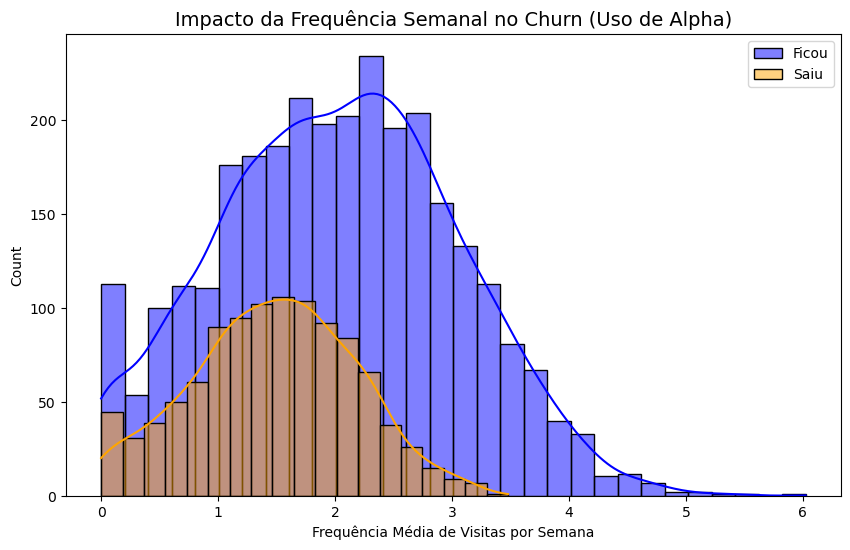

In [ ]:
# --- FIGURA 3: Resolvendo Overplotting ---
plt.figure(figsize=(10, 6))
sns.histplot(data=data[data['Churn'] == 0]['Avg_class_frequency_total'], 
             color='blue', label='Ficou', alpha=0.5, kde=True)
sns.histplot(data=data[data['Churn'] == 1]['Avg_class_frequency_total'], 
             color='orange', label='Saiu', alpha=0.5, kde=True)

plt.title('Impacto da Frequência Semanal no Churn (Uso de Alpha)', fontsize=14)
plt.xlabel('Frequência Média de Visitas por Semana')
plt.legend()
plt.savefig('./images/overplotting_alpha_frequencia.png', dpi=300, bbox_inches='tight')
plt.show()

## Seção 3

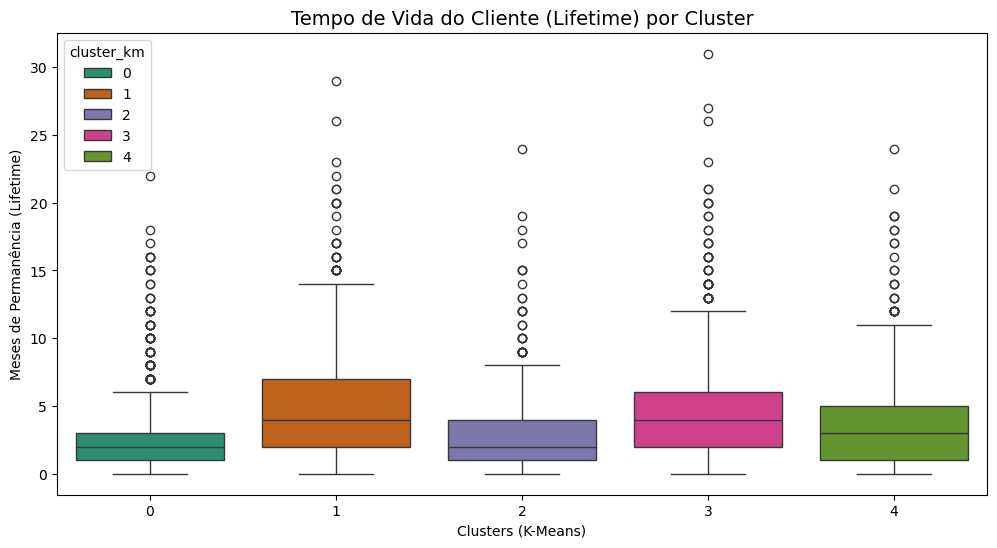

In [ ]:
# --- FIGURA 4: Box Plot Estrutural ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='cluster_km', y='Lifetime', palette='Dark2', hue='cluster_km')

plt.title('Tempo de Vida do Cliente (Lifetime) por Cluster', fontsize=14)
plt.xlabel('Clusters (K-Means)')
plt.ylabel('Meses de Permanência (Lifetime)')
plt.savefig('./images/boxplot_lifetime_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

## Seção 4

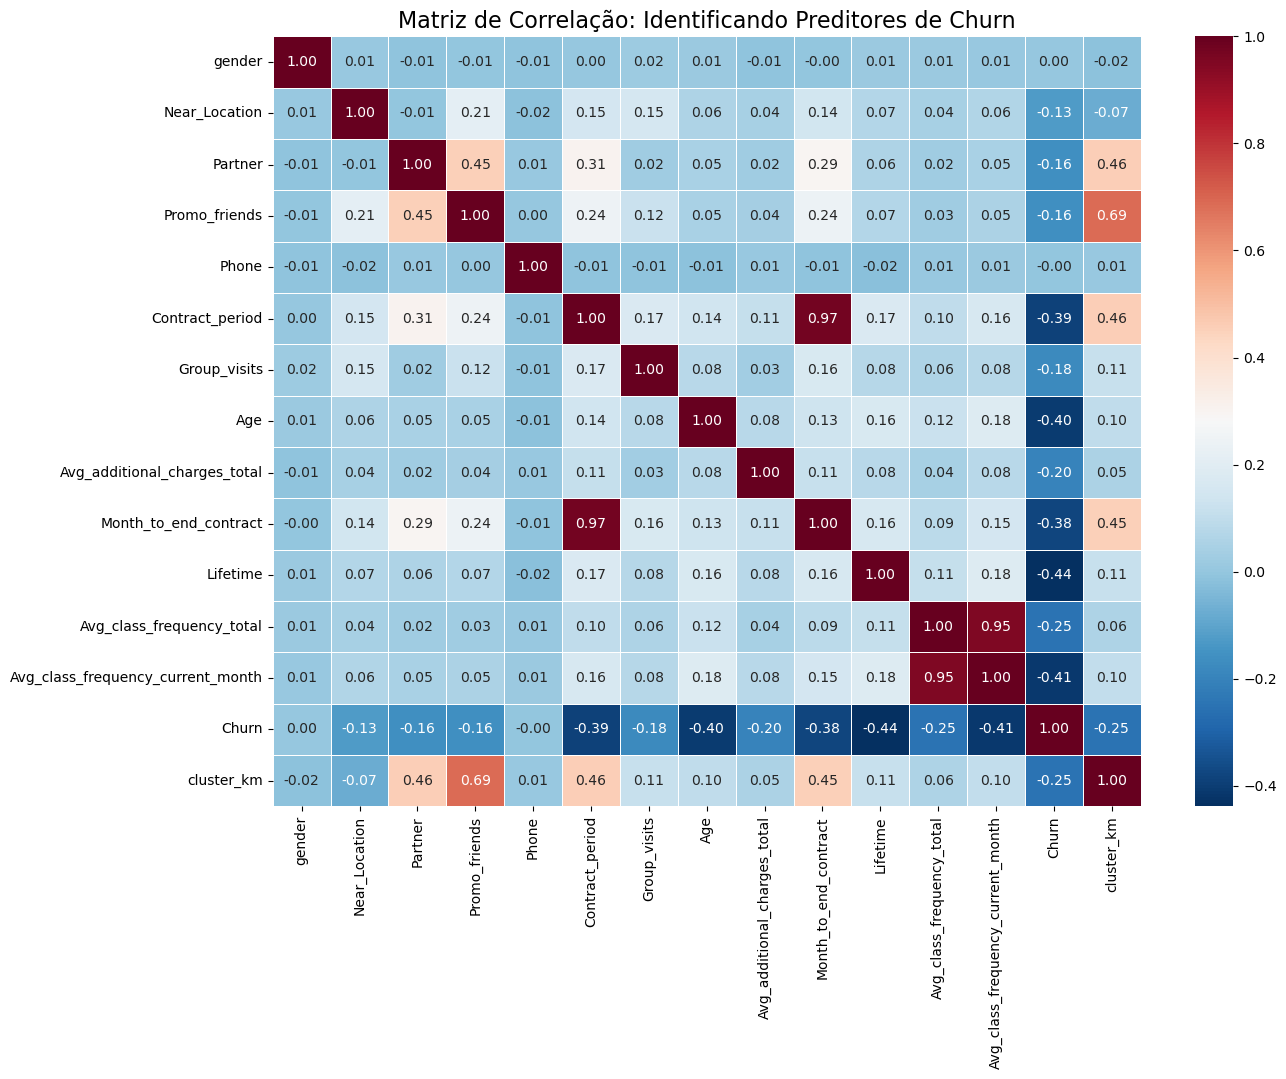

In [ ]:
# --- FIGURA 5: Heatmap de Correlação ---
corr_matrix = data.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação: Identificando Preditores de Churn', fontsize=16)
plt.savefig('./images/heatmap_correlacao_fitness.png', dpi=300, bbox_inches='tight')
plt.show()

# Conclusões

1. O cluster 0 é o principal grupo com o churn elevado, tambem apresenta uma baixa frequência de aulas comparado aos outros clusters sugerindo que esses clientes não estão engajados o suficiente para perceber valor no serviço. Uma estratégia seria um acompanhamento mais intensivo no(s) primeiros meses, garantindo que os usuários tenham conhecimento dos recursos disponíveis e como utilizá-los
2. os clusters que realizam um contrato de menor período tendem a cancelar mais (clusters 2 e 0), confirmando uma falta de renovação de contrato mais volátil sugerindo uma possível causa do churn. A curta duração pode indicar uma falta de compromisso/fidelidade no serviço que está sendo prestado quando o mesmo normalmente leva tempo até adquirir resultados significativos, uma estratégia para a realização de contratos mais longos seriam descontos ou benefícios que só são aplicáveis para contratos de maior duração
3. as participações em grupo são uma forma simples de criação de hábitos de atividade física, com um cronograma e objetivos específicos monitorados por um instrutor, facilitando o engajamento de usuários. Apesar de não ser causa direta de cancelamento, incentivar a participação em grupo pode reforçar o engajamento geral e prevenir futuras quedas de frequência. Pesquisas sobre horários/atividades preferidas melhoraria a participação em grupo